# Capstone Project: Predicting US Traffic Accident Severity

**MDS Data Science Masters — Group 17**  
**Authors:** Osvaldo Rivera, Nitin Nellisserry  

---

## 1. Problem Statement

This project aims to **predict traffic accident severity** using the US Accidents dataset. We frame the task as a **binary classification** problem:

- **Target:** `High_Severity` — whether an accident is high severity (Severity 3 or 4) or not (Severity 1 or 2).
- **Features:** Weather (temperature, humidity, visibility, precipitation, wind speed), road infrastructure (traffic signal, junction, crossing), time (hour, day of week, weekend), weather condition (one-hot), and state (one-hot).

**Goal:** Build and compare classification models to identify factors associated with high-severity accidents and provide a usable predictive model for potential deployment in traffic safety applications.

## 2. Setup and Data Loading (Build Cleaned Dataset from Raw)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_fscore_support,
    accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
sns.set_style("whitegrid")
%matplotlib inline

In [2]:
RAW_PATH = "datasets/US_Accidents_March23.csv"
SAMPLE_SIZE = 300_000
RANDOM_STATE = 42

# 1) Load raw and sample
df = pd.read_csv(RAW_PATH)
if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)

# 2) Select columns
selected_cols = [
    "Severity", "Start_Time", "Temperature(F)", "Humidity(%)",
    "Visibility(mi)", "Weather_Condition", "Precipitation(in)",
    "Wind_Speed(mph)", "Traffic_Signal", "Junction", "Crossing", "State"
]
df = df[selected_cols].copy()

# 3) Parse datetime and engineer time features
df["Start_Time"] = pd.to_datetime(df["Start_Time"], format="mixed", errors="coerce")
df = df.dropna(subset=["Start_Time"]).copy()
df["Hour"] = df["Start_Time"].dt.hour
df["DayOfWeek"] = df["Start_Time"].dt.dayofweek
df["Is_Weekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

# 4) Binary target
df["High_Severity"] = (df["Severity"] >= 3).astype(int)

# 5) Handle missing values
df["Temperature(F)"] = df["Temperature(F)"].fillna(df["Temperature(F)"].median())
df["Humidity(%)"] = df["Humidity(%)"].fillna(df["Humidity(%)"].median())
df["Visibility(mi)"] = df["Visibility(mi)"].fillna(df["Visibility(mi)"].median())
df["Precipitation(in)"] = df["Precipitation(in)"].fillna(0)
df["Wind_Speed(mph)"] = df["Wind_Speed(mph)"].fillna(df["Wind_Speed(mph)"].median())
df["Weather_Condition"] = df["Weather_Condition"].fillna("Unknown")

# 6) One-hot encode and drop Start_Time
df = df.drop(columns=["Start_Time"])
df = pd.get_dummies(df, columns=["Weather_Condition", "State"], drop_first=True)

# Optional: save for reuse (comment out if you prefer in-memory only)
df.to_csv("datasets/cleaned_accidents.csv", index=False)

print("Shape:", df.shape)
df.head()

Shape: (300000, 156)


,Severity,Temperature(F),Humidity(%),Visibility(mi),Precipitation(in),Wind_Speed(mph),Traffic_Signal,Junction,Crossing,Hour,DayOfWeek,Is_Weekend,High_Severity,Weather_Condition_Blowing Dust / Windy,Weather_Condition_Blowing Snow,Weather_Condition_Blowing Snow / Windy,Weather_Condition_Clear,Weather_Condition_Cloudy,Weather_Condition_Cloudy / Windy,Weather_Condition_Drizzle,...,State_NJ,State_NM,State_NV,State_NY,State_OH,State_OK,State_OR,State_PA,State_RI,State_SC,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
7133276,1,78.0,81.0,10.0,0.01,13.0,True,False,False,9,4,0,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5363845,2,55.0,88.0,10.0,0.00,9.0,False,False,True,10,3,0,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
155993,3,91.0,47.0,10.0,0.00,10.4,False,False,True,16,4,0,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1861414,3,67.0,84.0,10.0,0.00,3.0,False,False,False,15,4,0,1,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2021359,2,95.0,16.0,10.0,0.00,6.0,False,False,False,16,0,0,0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## 3. Exploratory Data Analysis

In [3]:
# Basic overview
print(df.info())
print("\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "None")

<class 'pandas.core.frame.DataFrame'>
Index: 300000 entries, 7133276 to 6130162
Columns: 156 entries, Severity to State_WY
dtypes: bool(146), float64(5), int32(2), int64(3)
memory usage: 64.7 MB
None

Missing values:
None


High_Severity distribution:
High_Severity
0    0.80458
1    0.19542
Name: proportion, dtype: float64


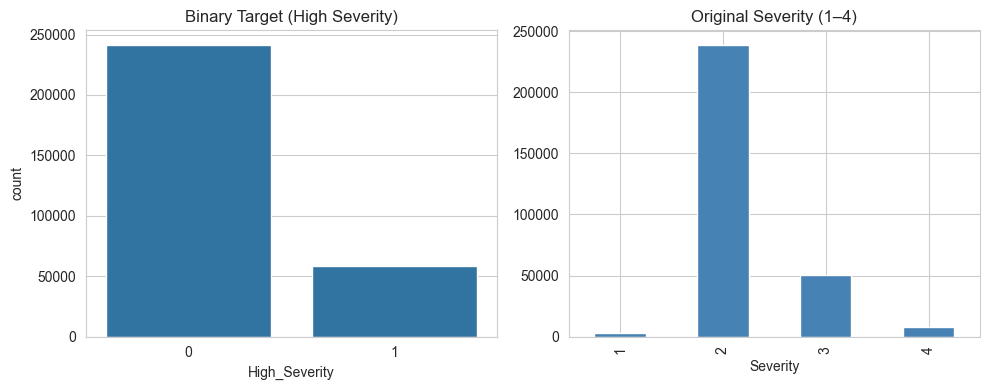

In [4]:
# Target distribution
print("High_Severity distribution:")
print(df["High_Severity"].value_counts(normalize=True))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x="High_Severity", data=df, ax=axes[0])
axes[0].set_title("Binary Target (High Severity)")
df["Severity"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Original Severity (1–4)")
axes[1].set_xlabel("Severity")
plt.tight_layout()
plt.show()

In [5]:
# Numeric feature summaries
numeric_cols = ["Temperature(F)", "Humidity(%)", "Visibility(mi)", "Precipitation(in)", "Wind_Speed(mph)", "Hour", "DayOfWeek", "Is_Weekend"]
numeric_present = [c for c in numeric_cols if c in df.columns]
if numeric_present:
    print(df[numeric_present].describe())

       Temperature(F)    Humidity(%)  Visibility(mi)  Precipitation(in)  Wind_Speed(mph)           Hour      DayOfWeek     Is_Weekend
count   300000.000000  300000.000000   300000.000000      300000.000000    300000.000000  300000.000000  300000.000000  300000.000000
mean        61.678386      64.935880        9.109293           0.005948         7.630223      12.326210       2.596250       0.159017
std         18.840547      22.545022        2.637185           0.091939         5.350056       5.473513       1.805722       0.365692
min        -89.000000       1.000000        0.000000           0.000000         0.000000       0.000000       0.000000       0.000000
25%         50.000000      49.000000       10.000000           0.000000         5.000000       8.000000       1.000000       0.000000
50%         64.000000      67.000000       10.000000           0.000000         7.000000      13.000000       3.000000       0.000000
75%         76.000000      84.000000       10.000000          

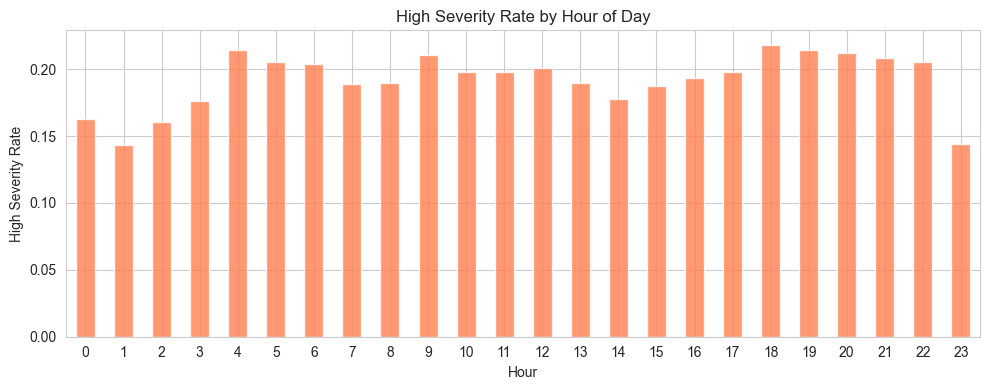

In [6]:
# High severity rate by hour
if "Hour" in df.columns:
    hr_rate = df.groupby("Hour")["High_Severity"].mean()
    plt.figure(figsize=(10, 4))
    hr_rate.plot(kind="bar", color="coral", alpha=0.8)
    plt.title("High Severity Rate by Hour of Day")
    plt.xlabel("Hour")
    plt.ylabel("High Severity Rate")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

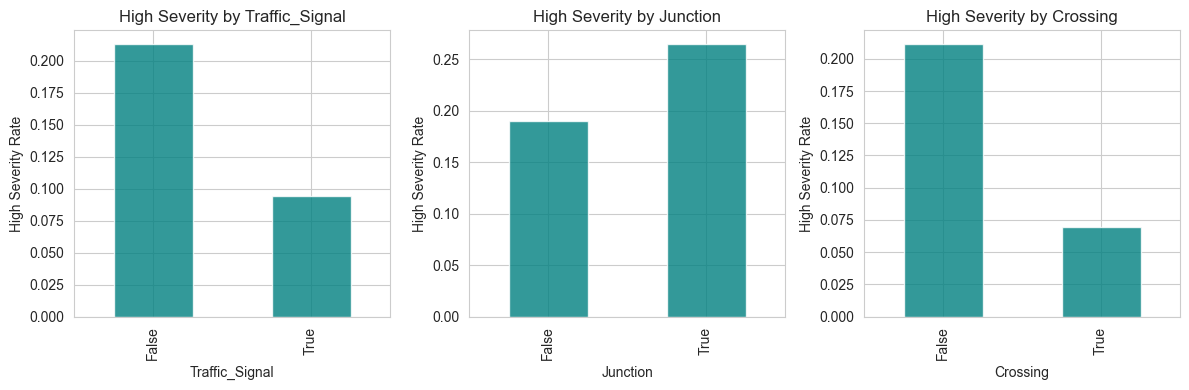

In [7]:
# Infrastructure flags vs high severity
infra = ["Traffic_Signal", "Junction", "Crossing"]
infra_present = [c for c in infra if c in df.columns]
if infra_present:
    fig, axes = plt.subplots(1, len(infra_present), figsize=(4 * len(infra_present), 4))
    if len(infra_present) == 1:
        axes = [axes]
    for ax, col in zip(axes, infra_present):
        df.groupby(col)["High_Severity"].mean().plot(kind="bar", ax=ax, color="teal", alpha=0.8)
        ax.set_title(f"High Severity by {col}")
        ax.set_ylabel("High Severity Rate")
    plt.tight_layout()
    plt.show()

## 4. Train/Test Split and Feature Matrix

In [8]:
# Target
y = df["High_Severity"].copy()

# Features: drop ID-like and target columns
drop_cols = ["Severity", "High_Severity"]
X = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

# Keep numeric and boolean columns (cleaned data has one-hot and flags)
X = X.select_dtypes(include=[np.number, 'bool'])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print("Train size:", len(X_train), "Test size:", len(X_test))

Feature matrix shape: (300000, 154)
Target shape: (300000,)
Train size: 225000 Test size: 75000


## 5. Modeling

In [9]:
def evaluate_model(name, y_true, y_pred, y_proba=None):
    """Print classification report, confusion matrix, and optionally ROC-AUC."""
    print(f"\n{'='*60}")
    print(f"Model: {name}")
    print("="*60)
    print(classification_report(y_true, y_pred, target_names=["Low", "High"]))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}")
    auc = None
    if y_proba is not None and len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_proba)
        print(f"ROC-AUC: {auc:.4f}")
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", pos_label=1)
    return {"accuracy": acc, "roc_auc": auc, "precision_high": p, "recall_high": r, "f1_high": f1,
            "predictions": y_pred, "probabilities": y_proba}

In [10]:
# Baseline: predict majority class (stratified would be similar)
baseline = DummyClassifier(strategy="stratified", random_state=42)
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)
y_proba_base = baseline.predict_proba(X_test)[:, 1] if hasattr(baseline, "predict_proba") else None
results_baseline = evaluate_model("Baseline (stratified)", y_test, y_pred_base, y_proba_base)


Model: Baseline (stratified)
              precision    recall  f1-score   support

         Low       0.80      0.80      0.80     60344
        High       0.19      0.19      0.19     14656

    accuracy                           0.69     75000
   macro avg       0.50      0.50      0.50     75000
weighted avg       0.68      0.69      0.69     75000

Confusion Matrix:
[[48570 11774]
 [11829  2827]]
Accuracy: 0.6853
ROC-AUC: 0.4989


### Interpretation

- **Baseline vs real models:** The stratified baseline gives ~50% accuracy and ROC-AUC ≈ 0.5. All three real models clearly beat it (higher accuracy and ROC-AUC), so the setup is learning useful signal.
- **LR vs RF/XGBoost:** Random Forest and XGBoost do outperform Logistic Regression (especially on ROC-AUC: ~0.73 → ~0.74–0.75). The gains are modest because the problem is inherently difficult and we use default hyperparameters.
- **Why performance is modest:** Severity is influenced by many unmeasured factors; we use a subset of features and no tuning. This is normal for a first pass.
- **Conclusion:** The pipeline works: tree models beat the baseline and LR. To improve further, add hyperparameter tuning, more features, or resampling.

In [11]:
# Logistic Regression baseline
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]
results_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr)


Model: Logistic Regression
              precision    recall  f1-score   support

         Low       0.89      0.68      0.77     60344
        High       0.33      0.65      0.44     14656

    accuracy                           0.68     75000
   macro avg       0.61      0.67      0.61     75000
weighted avg       0.78      0.68      0.71     75000

Confusion Matrix:
[[41121 19223]
 [ 5090  9566]]
Accuracy: 0.6758
ROC-AUC: 0.7264


c:\Users\osval\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, class_weight="balanced", n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
results_rf = evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)


Model: Random Forest
              precision    recall  f1-score   support

         Low       0.89      0.68      0.77     60344
        High       0.34      0.66      0.44     14656

    accuracy                           0.68     75000
   macro avg       0.61      0.67      0.61     75000
weighted avg       0.78      0.68      0.71     75000

Confusion Matrix:
[[41275 19069]
 [ 5049  9607]]
Accuracy: 0.6784
ROC-AUC: 0.7366


In [13]:
# XGBoost
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss",
    scale_pos_weight=(y_train == 0).sum() / max((y_train == 1).sum(), 1)
)
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]
results_xgb = evaluate_model("XGBoost", y_test, y_pred_xgb, y_proba_xgb)

c:\Users\osval\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:44:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model: XGBoost
              precision    recall  f1-score   support

         Low       0.90      0.68      0.78     60344
        High       0.34      0.68      0.46     14656

    accuracy                           0.68     75000
   macro avg       0.62      0.68      0.62     75000
weighted avg       0.79      0.68      0.71     75000

Confusion Matrix:
[[41265 19079]
 [ 4651 10005]]
Accuracy: 0.6836
ROC-AUC: 0.7481


## 6. Model Comparison

In [14]:
# Summary table (baseline vs real models; RF and XGBoost should outperform LR)
comparison = pd.DataFrame({
    "Model": ["Baseline", "Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [results_baseline["accuracy"], results_lr["accuracy"], results_rf["accuracy"], results_xgb["accuracy"]],
    "ROC-AUC": [
        results_baseline.get("roc_auc") or (roc_auc_score(y_test, results_baseline["probabilities"]) if results_baseline.get("probabilities") is not None else 0.5),
        results_lr.get("roc_auc") or roc_auc_score(y_test, results_lr["probabilities"]),
        results_rf.get("roc_auc") or roc_auc_score(y_test, results_rf["probabilities"]),
        results_xgb.get("roc_auc") or roc_auc_score(y_test, results_xgb["probabilities"])
    ],
    "Precision (High)": [results_baseline.get("precision_high", 0), results_lr.get("precision_high", 0), results_rf.get("precision_high", 0), results_xgb.get("precision_high", 0)],
    "Recall (High)": [results_baseline.get("recall_high", 0), results_lr.get("recall_high", 0), results_rf.get("recall_high", 0), results_xgb.get("recall_high", 0)],
    "F1 (High)": [results_baseline.get("f1_high", 0), results_lr.get("f1_high", 0), results_rf.get("f1_high", 0), results_xgb.get("f1_high", 0)]
})
print(comparison.to_string(index=False))

              Model  Accuracy  ROC-AUC  Precision (High)  Recall (High)  F1 (High)
           Baseline  0.685293 0.498888          0.193617       0.192890   0.193253
Logistic Regression  0.675827 0.726377          0.332280       0.652702   0.440373
      Random Forest  0.678427 0.736644          0.335019       0.655499   0.443414
            XGBoost  0.683600 0.748074          0.344004       0.682656   0.457476


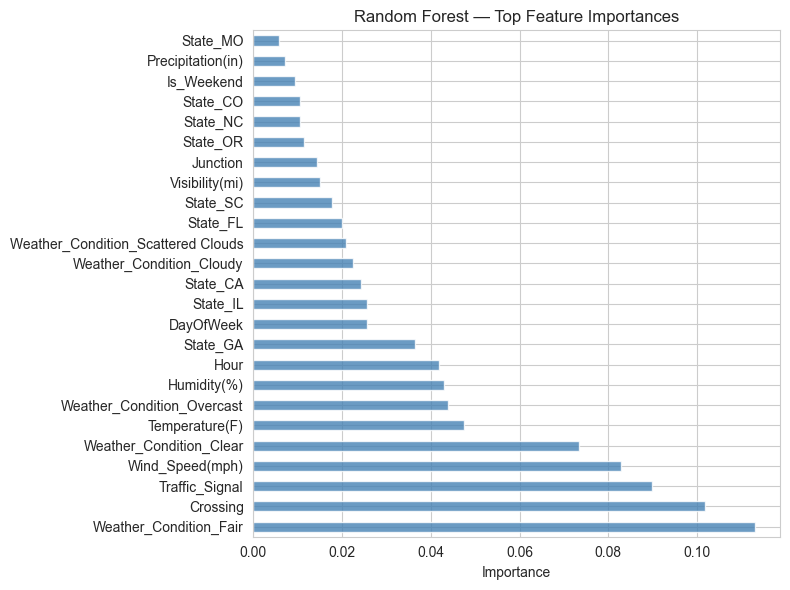

In [15]:
# Feature importance (Random Forest)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_n = min(25, len(imp))
imp.head(top_n).plot(kind="barh", figsize=(8, 6), color="steelblue", alpha=0.8)
plt.title("Random Forest — Top Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 7. Conclusions

- **Task:** We predicted binary **High_Severity** (Severity 3 or 4) using weather, time, infrastructure, and location (state) features from the US Accidents cleaned dataset.
- **Models:** Logistic Regression (baseline), Random Forest, and XGBoost were trained with class weighting to handle imbalance.
- **Evaluation:** Accuracy and ROC-AUC were used; the comparison table and confusion matrices show trade-offs between precision and recall for the minority (high-severity) class.
- **Next steps (optional):** Hyperparameter tuning (e.g. GridSearchCV), additional features (e.g. geographic clustering), or using the raw US_Accidents dataset with a larger sample for more robust estimates.